# **Phase 4 - Business Analytics**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [5]:
import os

os.listdir('/content')

['.config',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'product_category_name_translation.csv',
 'master_dataset.csv',
 'olist_order_items_dataset.csv',
 'sample_data']

In [7]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

In [8]:
customers.head()
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
print(customers.shape)
print(orders.shape)
print(order_items.shape)

(99441, 5)
(99441, 8)
(112650, 7)


In [11]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

In [12]:
products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [13]:
master = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(payments, on="order_id", how="left")
    .merge(reviews, on="order_id", how="left")
)

In [14]:
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


In [15]:
master.shape

(119143, 37)

In [16]:
master.to_csv("master_dataset.csv", index=False)

In [17]:
print(os.listdir())

['.config', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'product_category_name_translation.csv', 'master_dataset.csv', 'olist_order_items_dataset.csv', 'sample_data']


In [18]:
master.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

# **Section A - Customer Analytics**
**Business Question 1**


How many unique customers do we have?

In [19]:
total_customers = master['customer_unique_id'].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 96096


**Business Question 2**


Top 10 States by Customers

In [21]:
top_states = (
    master.groupby('customer_state')['customer_unique_id']
          .nunique()
          .sort_values(ascending=False)
)

top_states.head(10)

,customer_unique_id
customer_state,
SP,40302
RJ,12384
MG,11259
RS,5277
PR,4882
SC,3534
BA,3277
DF,2075
ES,1964


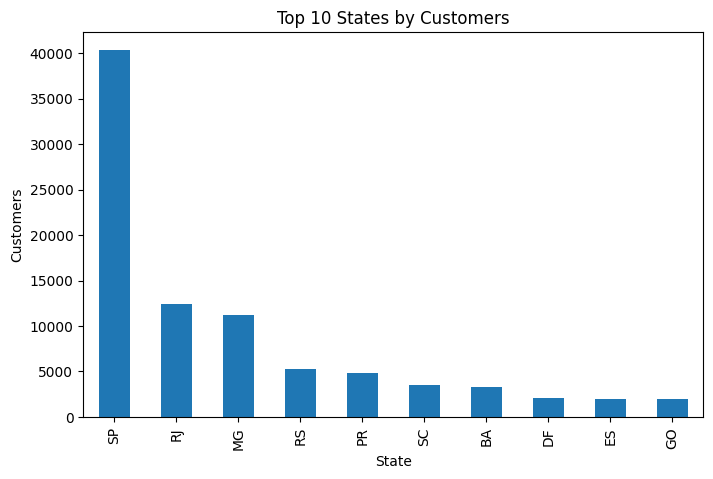

In [22]:
top_states.head(10).plot(kind='bar', figsize=(8,5))

plt.title("Top 10 States by Customers")
plt.xlabel("State")
plt.ylabel("Customers")

plt.show()

**Business Question 3**


Top Cities

In [23]:
top_cities = (
    master.groupby('customer_city')['customer_unique_id']
          .nunique()
          .sort_values(ascending=False)
)

top_cities.head(10)

,customer_unique_id
customer_city,
sao paulo,14984
rio de janeiro,6620
belo horizonte,2672
brasilia,2069
curitiba,1465
campinas,1398
porto alegre,1326
salvador,1209
guarulhos,1153


# **Section B-Revenue Analytics**
**Business Question 4**


Total Revenue

In [24]:
total_revenue = master['payment_value'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 20579664.01


**Business Question 5**


Monthly Revenue

In [25]:
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])

master['Month'] = (
    master['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

monthly_revenue = (
    master.groupby('Month')['payment_value']
          .sum()
)

monthly_revenue

,payment_value
Month,
2016-09,388.47
2016-10,76559.05
2016-12,19.62
2017-01,190806.27
2017-02,351848.13
2017-03,547769.84
2017-04,512126.52
2017-05,737425.31
2017-06,613777.41


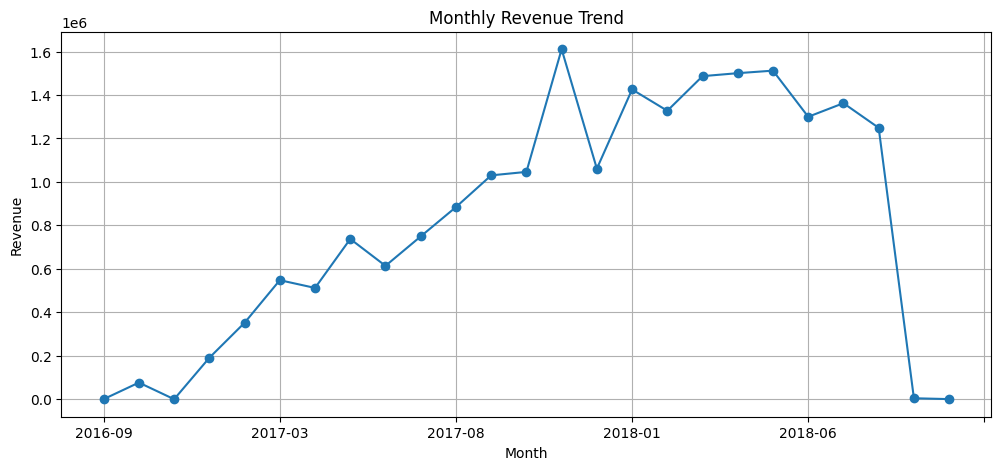

In [26]:
monthly_revenue.plot(figsize=(12,5), marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

**Business Question 6**


Average Order Value (AOV)

In [28]:
average_order_value = (
    master.groupby('order_id')['payment_value']
          .sum()
          .mean()
)

print("Average Order Value:", round(average_order_value,2))

Average Order Value: 206.95


# **Section C - Product Analytics**
**Business Question 7**


Top Selling Categories

In [29]:
top_categories = (
    master.groupby('product_category_name_english')['order_item_id']
          .count()
          .sort_values(ascending=False)
)

top_categories.head(10)

,order_item_id
product_category_name_english,
bed_bath_table,11988
health_beauty,10032
sports_leisure,9004
furniture_decor,8832
computers_accessories,8150
housewares,7380
watches_gifts,6213
telephony,4726
garden_tools,4590


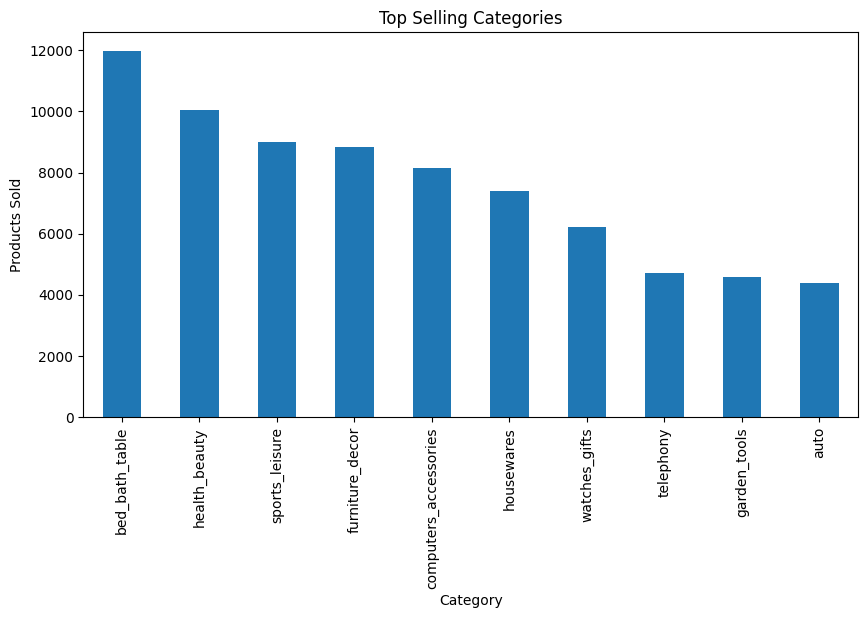

In [30]:
top_categories.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Selling Categories")

plt.xlabel("Category")

plt.ylabel("Products Sold")

plt.show()

**Business Question 8**


Highest Revenue Categories

In [31]:
category_revenue = (
    master.groupby('product_category_name_english')['payment_value']
          .sum()
          .sort_values(ascending=False)
)

category_revenue.head(10)

,payment_value
product_category_name_english,
bed_bath_table,1743998.80
health_beauty,1662963.59
computers_accessories,1599481.06
furniture_decor,1443963.61
watches_gifts,1430553.48
sports_leisure,1400223.07
housewares,1097900.09
auto,855095.68
garden_tools,840721.59


**Business Question 9**


Highest Rated Categories

In [32]:
category_rating = (
    master.groupby('product_category_name_english')['review_score']
          .mean()
          .sort_values(ascending=False)
)

category_rating.head(10)

,review_score
product_category_name_english,
cds_dvds_musicals,4.642857
fashion_childrens_clothes,4.500000
books_general_interest,4.438503
books_imported,4.419355
flowers,4.419355
costruction_tools_tools,4.415842
books_technical,4.375465
food_drink,4.324138
small_appliances_home_oven_and_coffee,4.320513


# **Section D - Customer Experience**
**Business Question 10**


Average Review Score

In [33]:
average_rating = master['review_score'].mean()

print("Average Review Score:", round(average_rating,2))

Average Review Score: 4.02


**Business Question 11**


Review Score Distribution

In [34]:
review_distribution = (
    master['review_score']
    .value_counts()
    .sort_index()
)

review_distribution

,count
review_score,
1.0,15428
2.0,4162
3.0,9894
4.0,22319
5.0,66343


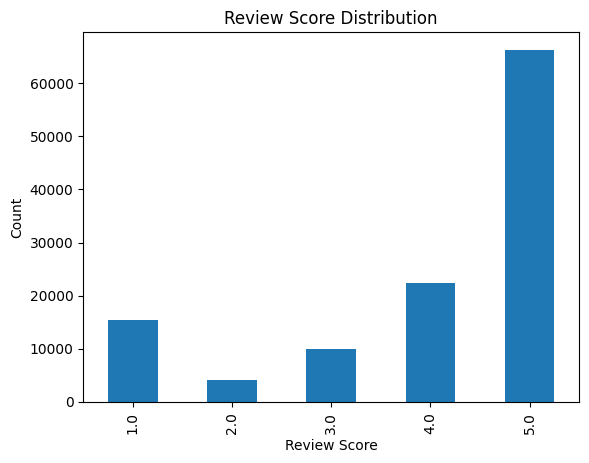

In [35]:
review_distribution.plot(kind='bar')

plt.title("Review Score Distribution")

plt.xlabel("Review Score")

plt.ylabel("Count")

plt.show()

# **Section E - Delivery Performance**
**Business Question 12**


Average Delivery Time

In [37]:
# Convert to datetime
master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])
master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'])

# Create delivery_days
master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

In [38]:
average_delivery = master['delivery_days'].mean()

print("Average Delivery Time:", round(average_delivery,2),"days")

Average Delivery Time: 12.02 days


**Business Question 13**


Late Deliveries

In [40]:
master["delivery_delay_days"] = (
    master["order_delivered_customer_date"] -
    master["order_estimated_delivery_date"]
).dt.days

In [41]:
late_orders = master[master['delivery_delay_days'] > 0]

print("Late Deliveries:", len(late_orders))

Late Deliveries: 7559


**Business Question 14**


Average Delivery Delay

In [42]:
average_delay = master['delivery_delay_days'].mean()

print("Average Delay:", round(average_delay,2))

Average Delay: -12.05


# **Section F - Payment Analytics**
**Business Question 15**


Most Used Payment Method

In [43]:
payment_methods = (
    master['payment_type']
    .value_counts()
)

payment_methods

,count
payment_type,
credit_card,87776
boleto,23190
voucher,6465
debit_card,1706
not_defined,3


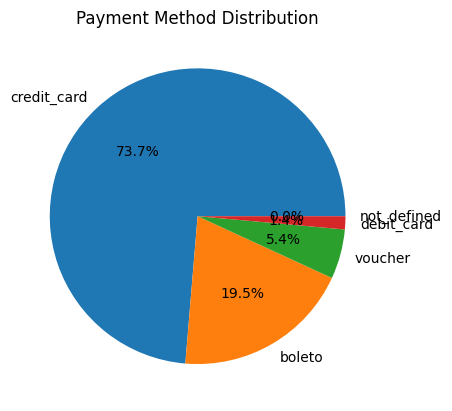

In [44]:
payment_methods.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Method Distribution")

plt.ylabel("")

plt.show()

# **Section G - Seller Analytics**
**Business Question 16**


Top Sellers by Revenue

In [45]:
top_sellers = (
    master.groupby('seller_id')['payment_value']
          .sum()
          .sort_values(ascending=False)
)

top_sellers.head(10)

,payment_value
seller_id,
7c67e1448b00f6e969d365cea6b010ab,512645.19
1025f0e2d44d7041d6cf58b6550e0bfa,312456.49
4a3ca9315b744ce9f8e9374361493884,306138.80
1f50f920176fa81dab994f9023523100,291918.98
53243585a1d6dc2643021fd1853d8905,284903.08
da8622b14eb17ae2831f4ac5b9dab84a,276578.63
4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
955fee9216a65b617aa5c0531780ce60,236414.48
fa1c13f2614d7b5c4749cbc52fecda94,206513.23


# **Section H - Executive KPI Table**

In [46]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Revenue",
        "Average Order Value",
        "Average Review Score",
        "Average Delivery Time"
    ],
    "Value": [
        total_customers,
        round(total_revenue,2),
        round(average_order_value,2),
        round(average_rating,2),
        round(average_delivery,2)
    ]
})

kpi_summary

,KPI,Value
0,Total Customers,96096.00
1,Total Revenue,20579664.01
2,Average Order Value,206.95
3,Average Review Score,4.02
4,Average Delivery Time,12.02
